In [1]:
import numpy as np
import sympy as sp
import tqdm
import segyio
import gc

import matplotlib.pyplot as plt

from devito import *
from examples.seismic.source import RickerSource, WaveletSource, TimeAxis
from examples.seismic import ModelViscoacoustic, plot_image, setup_geometry, plot_velocity

from devito import configuration
#(a) using one GPU
#(b) using multi-GPUs with MPI (requires turning the notebook into a python script)
configuration['platform'] = 'nvidiaX'
configuration['compiler'] = 'pgcc'
configuration['language'] = 'openacc'

In [2]:
def create_parallelogram_mask(shape, center_x=None, center_z=None, width=50, height=30, angle_degrees=30):
    nx, nz = shape
    
    # Default to center if not specified
    if center_x is None:
        center_x = nx // 2
    if center_z is None:
        center_z = nz // 2
    
    # Convert angle to radians
    angle_rad = np.radians(angle_degrees)
    
    # Create coordinate arrays
    x = np.arange(nx)
    z = np.arange(nz)
    X, Z = np.meshgrid(x, z)
    
    # Center coordinates
    X_centered = X - center_x
    Z_centered = Z - center_z
    
    # Calculate the horizontal skew based on the angle
    skew = height * np.tan(angle_rad)
    
    # Transform to parallelogram coordinates
    # In these coordinates, the parallelogram becomes an axis-aligned rectangle
    X_prime = X_centered - (Z_centered / height) * skew
    Z_prime = Z_centered
    
    # Create mask: points inside the axis-aligned rectangle in transformed coordinates
    mask = (np.abs(X_prime) < width/2) & (np.abs(Z_prime) < height/2)
    
    return mask.T

In [3]:
spacing = (5., 5.)
shape = (401, 101)
origin = (0., 0.)
nlayers = 5
nbl = 200
space_order=8

# Model physical parameters:
vp = np.zeros(shape)
qp = np.zeros(shape)
rho = np.zeros(shape)

# Define a velocity profile. The velocity is in km/s
vp_top = 4
vp_bottom = 5.5

# Define a velocity profile in km/s
v = np.empty(shape, dtype=np.float32)
v[:] = vp_top  # Top velocity (background)
vp_i = np.linspace(vp_top, vp_bottom, nlayers)
for i in range(1, nlayers):
    v[..., i*int(shape[-1] / nlayers):] = vp_i[i]  # Bottom velocity

qp[:] = 3.516*((v[:]*1000.)**2.2)*10**(-6) # Li's empirical formula

rho[:] = 0.31*(v[:]*1000.)**0.25 # Gardner's relation

In [4]:
mask = create_parallelogram_mask(
    shape=shape,  # (nx, nz)
    center_x=200,      # x position of center
    center_z=49.5,      # z position of center  
    width=10,          # width in grid points
    height=60.5,         # height in grid points
    angle_degrees=-30   # tilt angle
)

In [5]:
v[mask] *= .7
rho[mask] *= .7
qp[mask] *= .7

In [6]:
v

array([[4. , 4. , 4. , ..., 5.5, 5.5, 5.5],
       [4. , 4. , 4. , ..., 5.5, 5.5, 5.5],
       [4. , 4. , 4. , ..., 5.5, 5.5, 5.5],
       ...,
       [4. , 4. , 4. , ..., 5.5, 5.5, 5.5],
       [4. , 4. , 4. , ..., 5.5, 5.5, 5.5],
       [4. , 4. , 4. , ..., 5.5, 5.5, 5.5]], dtype=float32)

In [7]:
def compute_rms_velocities_2d(velocity_model, thicknesses):
    """
    Compute running RMS velocities for a 2D velocity model.
    For each depth level, RMS is computed using all layers from top to that depth.
    
    Parameters:
    -----------
    velocity_model : 2D numpy array
        Shape (n_layers, n_columns) - velocities for each layer and column
    thicknesses : 1D numpy array  
        Thicknesses for each layer (same for all columns)
        
    Returns:
    --------
    rms_velocities : 2D numpy array
        RMS velocities with same shape as input, where each cell contains
        the RMS velocity from surface down to that depth
    """
    n_layers, n_columns = velocity_model.shape
    rms_velocities = np.zeros_like(velocity_model)
    
    # For each column
    for col in range(n_columns):
        velocities_col = velocity_model[:, col]
        
        # For each depth level in this column
        for depth in range(n_layers):
            # Use layers from top (0) to current depth level
            v_slice = velocities_col[:depth+1]
            h_slice = thicknesses[:depth+1]
            
            # Compute RMS for layers 0 to depth
            numerator = np.sum(h_slice * v_slice)
            denominator = np.sum(h_slice / v_slice)
            rms_vel = np.sqrt(numerator / denominator)
            
            rms_velocities[depth, col] = rms_vel
    
    return rms_velocities

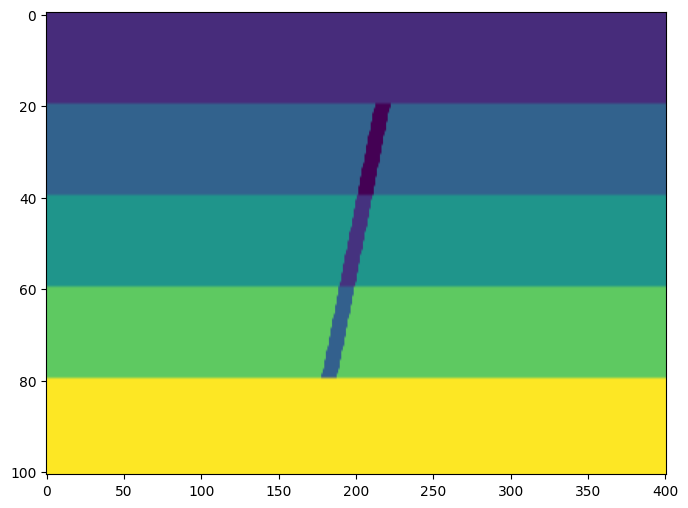

In [8]:
plt.imshow(qp.T, aspect="auto")

In [9]:
#NBVAL_IGNORE_OUTPUT
model = ModelViscoacoustic(space_order=space_order, vp=v, qp=qp, b=1/rho, 
                           origin=origin, shape=shape, spacing=spacing, 
                           nbl=nbl)

Operator `initdamp` ran in 0.16 s


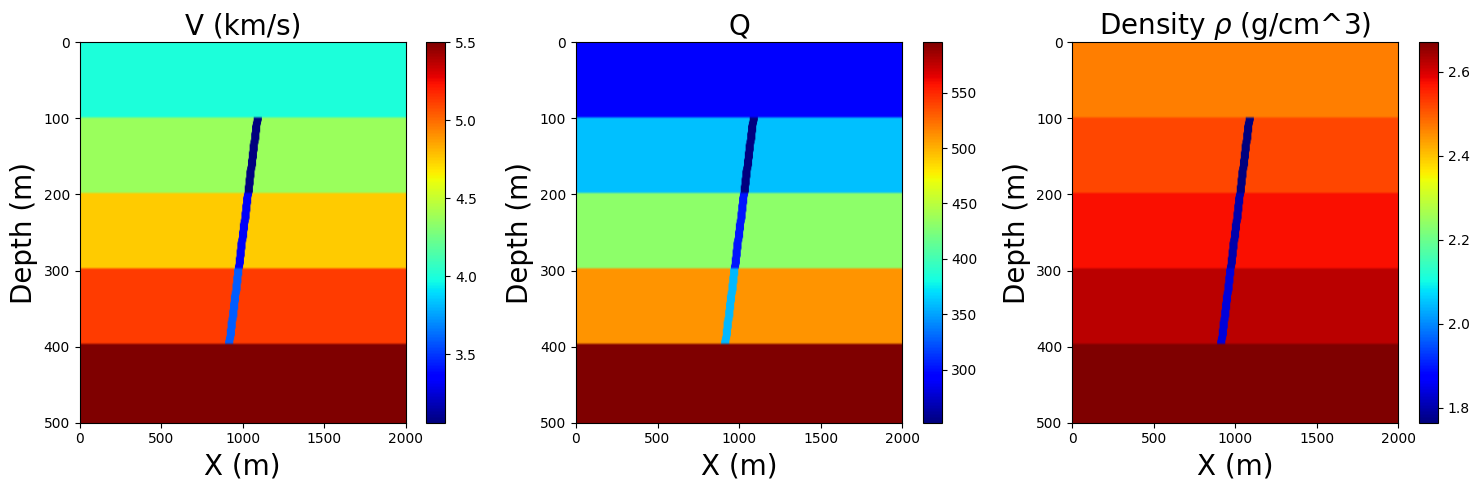

In [10]:
#NBVAL_IGNORE_OUTPUT
aspect_ratio = model.shape[0]/model.shape[1]

plt_options_model = {'cmap': 'jet', 'extent': [model.origin[0], model.origin[0] + model.domain_size[0],
                                               model.origin[1] + model.domain_size[1], model.origin[1]]}
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

slices = [slice(model.nbl, -model.nbl), slice(model.nbl, -model.nbl)]

img1 = ax[0].imshow(np.transpose(model.vp.data[slices]), **plt_options_model)
fig.colorbar(img1, ax=ax[0])
ax[0].set_title(r"V (km/s)", fontsize=20)
ax[0].set_xlabel('X (m)', fontsize=20)
ax[0].set_ylabel('Depth (m)', fontsize=20)
ax[0].set_aspect('auto')

img2 = ax[1].imshow(np.transpose(qp), **plt_options_model)
fig.colorbar(img2, ax=ax[1])
ax[1].set_title("Q", fontsize=20)
ax[1].set_xlabel('X (m)', fontsize=20)
ax[1].set_ylabel('Depth (m)', fontsize=20)
ax[1].set_aspect('auto')

img3 = ax[2].imshow(np.transpose(rho), **plt_options_model)
fig.colorbar(img3, ax=ax[2])
ax[2].set_title(r"Density $\rho$ (g/cm^3)", fontsize=20)
ax[2].set_xlabel('X (m)', fontsize=20)
ax[2].set_ylabel('Depth (m)', fontsize=20)
ax[2].set_aspect('auto')

plt.tight_layout()

In [11]:
f0 = 0.025 # peak/dominant frequency 
b = model.b
rho = 1./b

# velocity model
vp = model.vp
lam = vp * vp * rho

t_s = (sp.sqrt(1.+1./model.qp**2)-1./model.qp)/f0
t_ep = 1./(f0**2*t_s)
tt = (t_ep/t_s) - 1.

s = model.grid.stepping_dim.spacing
damp = model.damp

In [12]:
# Time step in ms and time range:
t0, tn = 0., 1500.
dt = model.critical_dt
time_range = TimeAxis(start=t0, stop=tn, step=dt)

In [13]:
from examples.seismic import Receiver

def src_rec(p, model):
    src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=time_range)
    src.coordinates.data[0, :] = np.array(model.domain_size) * .5
    src.coordinates.data[0, -1] = 8.  

    # Create symbol for receivers
    rec = Receiver(name='rec', grid=model.grid, npoint=shape[0], time_range=time_range)

    # Prescribe even spacing for receivers along the x-axis
    rec.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec.coordinates.data[:, 1] = 8.  

    src_term = src.inject(field=p.forward, expr=(s*src))
    rec_term = rec.interpolate(expr=p)
    
    return src_term + rec_term, src, rec

Auxiliary functions for plotting data:

In [14]:
def plot_receiver(rec):
    rec_plot = rec.resample(num=1001)
    scale_for_plot = np.diag(np.linspace(1.0, 2.5, 1001)**2.0)
    # Pressure (txx + tzz) data at sea surface
    extent = [rec_plot.coordinates.data[0, 0], rec_plot.coordinates.data[-1, 0], 1e-3*tn, t0]
    aspect = rec_plot.coordinates.data[-1, 0]/(1e-3*tn)/.5

    plt.figure(figsize=(10, 10))
    plt.imshow(np.dot(scale_for_plot, rec_plot.data), vmin=-.01, vmax=.01, cmap="seismic",
           interpolation='lanczos', extent=extent, aspect=aspect)
    plt.ylabel("Time (s)", fontsize=20)
    plt.xlabel("Receiver position (m)", fontsize=20)

In [15]:
def plot_v_and_p(model, v, p):
    
    slices = [slice(model.nbl, -model.nbl), slice(model.nbl, -model.nbl)]
    scale = .5*1e-3

    plt_options_model = {'extent': [model.origin[0] , model.origin[0] + model.domain_size[0],
                                    model.origin[1] + model.domain_size[1], model.origin[1]]}

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 7))

    ax[0].imshow(np.transpose(v[0].data[0][slices]), vmin=-scale, vmax=scale, cmap="RdGy", **plt_options_model)
    ax[0].imshow(np.transpose(model.vp.data[slices]), vmin=1.5, vmax=3.5, cmap="jet", alpha=.5, **plt_options_model)
    ax[0].set_aspect('auto')
    ax[0].set_xlabel('X (m)', fontsize=20)
    ax[0].set_ylabel('Depth (m)', fontsize=20)
    ax[0].set_title(r"$v_{x}$", fontsize=20)

    ax[1].imshow(np.transpose(v[1].data[0][slices]), vmin=-scale, vmax=scale, cmap="RdGy", **plt_options_model)
    ax[1].imshow(np.transpose(model.vp.data[slices]), vmin=1.5, vmax=3.5, cmap="jet", alpha=.5, **plt_options_model)
    ax[1].set_aspect('auto')
    ax[1].set_xlabel('X (m)', fontsize=20)
    ax[1].set_title(r"$v_{z}$", fontsize=20)

    ax[2].imshow(np.transpose(p.data[0][slices]), vmin=-scale, vmax=scale, cmap="RdGy", **plt_options_model)
    ax[2].imshow(np.transpose(model.vp.data[slices]), vmin=1.5, vmax=3.5, cmap="jet", alpha=.5, **plt_options_model)
    ax[2].set_aspect('auto')
    ax[2].set_xlabel('X (m)', fontsize=20)
    ax[2].set_title(r"$P$", fontsize=20)

## Equation based on Maxwell rheological model

The viscoacoustic wave equation for the propagating pressure $P$ in the
time-space domain:

where $g$ is the absorption coefficient, given by:

The equation can be written using a first order formulation, given by:

In [16]:
# Stencil created from Deng and McMechan (2007) viscoacoustic wave equation.
def Maxwell(model, p, v):

    # Angular frequency 
    w = 2. * np.pi * f0

    # Define PDE to v
    pde_v = v.dt + b * grad(p)
    u_v = Eq(v.forward, damp * solve(pde_v, v.forward))

    # Define PDE to p
    pde_p = p.dt + lam * div(v.forward) + (w / model.qp) * p
    u_p = Eq(p.forward, damp * solve(pde_p, p.forward))
    
    return [u_v, u_p]

In [17]:
def create_src(p, model, src_coords):
    src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=time_range)
    src.coordinates.data[0, :] = src_coords
    src.coordinates.data[0, -1] = 0.  

    # Create symbol for receivers
    rec = Receiver(name='rec', grid=model.grid, npoint=shape[0], time_range=time_range)

    # Prescribe even spacing for receivers along the x-axis
    rec.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec.coordinates.data[:, 1] = 0.  

    src_term = src.inject(field=p.forward, expr=(s*src))
    rec_term = rec.interpolate(expr=p)
    
    return src_term + rec_term, src, rec

In [18]:
# Seismic Modelling from Deng and McMechan (2007) viscoacoustic wave equation.
def modelling_Maxwell(model, src_coord):
    
    # Create symbols for particle velocity, pressure field, source and receivers
    
    v = VectorTimeFunction(name="v", grid=model.grid, time_order=1, space_order=space_order)

    p = TimeFunction(name="p", grid=model.grid, time_order=1, space_order=space_order, 
                     staggered=NODE)

    # define the source injection and create interpolation expression for receivers
    
    src_rec_expr, src, rec = create_src(p, model, src_coord)
    
    eqn = Maxwell(model, p, v)
    
    op = Operator(eqn + src_rec_expr, subs=model.spacing_map)
    
    op(time=time_range.num-1, dt=dt, src=src, rec=rec)
    
    return rec, v, p

In [19]:
src_coords = np.linspace(0, model.domain_size[0], num=shape[0])
pbar = tqdm.tqdm(src_coords)
path = "../../results/2d_viscoacoustic/Maxwell_200_width"

for src_coord in pbar:
    pbar.set_description(f"Processing {src_coord} source")
    rec, _, _ = modelling_Maxwell(model, src_coord)

    dt_r = 0.25
    rec_v = rec.resample(dt=dt_r)
    # segyio.tools.from_array2D(path +'/2d_maxwell_viscoacoustic_SRC-'+str(int(src_coord))+'.sgy', rec_v.data.T, dt=dt_r*10**3)
    # with segyio.open(path +'/2d_maxwell_viscoacoustic_SRC-'+str(int(src_coord))+'.sgy', 'r+') as f:
    #     for j in range(len(f.header)):
    #         f.header[j] = {segyio.TraceField.SourceX : int(src_coord),
    #                        segyio.TraceField.GroupX : np.array(rec_v.coordinates.data[j,0], dtype = int)
    #                        }
    
    gc.collect()

Processing 30.0 source:   1%|▏         | 6/401 [00:09<09:55,  1.51s/it]


KeyboardInterrupt: 

In [ ]:
#NBVAL_IGNORE_OUTPUT
# rec, v, p = modelling_Maxwell(model)

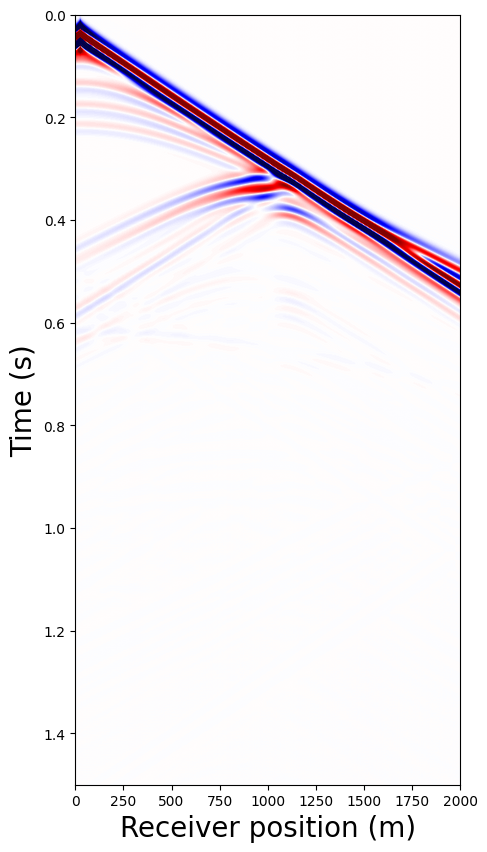

In [20]:
#NBVAL_IGNORE_OUTPUT
plot_receiver(rec)